# EEG_09b — HGNN Subject-Specific Ranking (LOSO)

Hypergraph Neural Network (Feng et al. 2019) in modalita' subject-specific.
Split: Leave-One-Session-Out — test=S005, val=S004, train=S001-S003.
Metrica fissa: abs_pcc pruned (migliore da EEG_07f).
Output: ranking soggetti per test bAcc (top1 + top2).


In [ ]:
import json, logging, re, time
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import balanced_accuracy_score, recall_score
from tqdm.auto import tqdm
import wandb

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)-8s %(message)s', datefmt='%H:%M:%S')
log = logging.getLogger('eeg09b')

project_root = next((p for p in [Path.cwd()]+list(Path.cwd().parents) if (p/'.git').exists()), Path.cwd())
FIG_DIR  = project_root / 'figures'; FIG_DIR.mkdir(exist_ok=True)
CKPT_DIR = project_root / 'models' / 'eeg09b'; CKPT_DIR.mkdir(parents=True, exist_ok=True)

# ---- CONFIG ----
N_CHANNELS = 61
N_SAMPLES  = 384
METRIC    = 'abs_pcc'
PRUNED    = True
N_CLASSES = 4
CLUSTER_SCHEME = 'concr4'

LR           = 1e-3
WEIGHT_DECAY = 1e-3    # alzato da 1e-4 — contrasta overfitting S-Spec
GRAD_CLIP    = 1.0
BATCH_SIZE   = 32
MAX_EPOCHS   = 80
PATIENCE     = 15
HIDDEN       = 128
N_LAYERS     = 2
DROPOUT      = 0.5     # alzato da 0.3 — S-Spec ~330 trial/sogg.
LABEL_SMOOTHING   = 0.1
USE_INSTANCE_NORM = True

# Data augmentation — solo su training set
USE_AUGMENTATION = True
AUG_NOISE_STD    = 0.05
AUG_AMP_RANGE    = (0.85, 1.15)
AUG_SHIFT_MAX    = 15
AUG_MASK_LEN     = 20

WANDB_ENTITY  = 'uras-daniele22-politecnico-di-milano'
WANDB_PROJECT = 'miralis-imagined-speech'

_PAT  = re.compile(r'^P(\d+)_S(\d+)$')
label2cluster = {int(k): int(v) for k,v in json.loads(
    (project_root/'configs'/'label_schemes'/'labelid2cluster_concr4.json').read_text()).items()}

kind = 'hypergraphs_pruned' if PRUNED else 'hypergraphs'
HG_ROOT = project_root / 'data' / f'{kind}_{METRIC}'

# raccolta path per soggetto -> sessione
subj_sess = defaultdict(lambda: defaultdict(list))
for p in sorted(HG_ROOT.rglob('trial_*.pt')):
    m = _PAT.match(p.parent.name)
    if m:
        subj_sess[int(m.group(1))][int(m.group(2))].append(p)

ALL_SUBJ = sorted(subj_sess.keys())
log.info(f'HG_ROOT: {HG_ROOT}')
log.info(f'Soggetti: {len(ALL_SUBJ)}  — {ALL_SUBJ[:5]}...')
log.info(f'DROPOUT={DROPOUT}  WEIGHT_DECAY={WEIGHT_DECAY}  GRAD_CLIP={GRAD_CLIP}  USE_AUG={USE_AUGMENTATION}')

## §2 — Dataset + Split LOSO

In [ ]:
def _augment_eeg(x: torch.Tensor) -> torch.Tensor:
    x = x.clone()
    if torch.rand(1) < 0.5:
        x = x + torch.randn_like(x) * AUG_NOISE_STD
    if torch.rand(1) < 0.5:
        x = x * torch.empty(1).uniform_(*AUG_AMP_RANGE)
    if torch.rand(1) < 0.5:
        shift = torch.randint(-AUG_SHIFT_MAX, AUG_SHIFT_MAX + 1, (1,)).item()
        x = torch.roll(x, shift, dims=1)
    if torch.rand(1) < 0.3:
        T = x.shape[1]
        start = torch.randint(0, max(1, T - AUG_MASK_LEN), (1,)).item()
        x[:, start:start + AUG_MASK_LEN] = 0.0
    if torch.rand(1) < 0.2:
        ch = torch.randint(0, x.shape[0], (1,)).item()
        x[ch] = 0.0
    return x


class HGDatasetSSPaths(Dataset):
    def __init__(self, paths_and_labels, use_instance_norm=True, augment=False):
        self.items = paths_and_labels
        self.use_instance_norm = use_instance_norm
        self.augment = augment

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        p, label = self.items[idx]
        d = torch.load(p, weights_only=False)
        x = d['x'].float()   # (61, 384)
        H = d['H'].float()   # (61, E)
        if self.use_instance_norm:
            x = (x - x.mean(dim=1, keepdim=True)) / (x.std(dim=1, keepdim=True) + 1e-6)
        if self.augment:
            x = _augment_eeg(x)
        # pad/tronca H a (N_CHANNELS, N_CHANNELS)
        if H.shape[1] < N_CHANNELS:
            H = F.pad(H, (0, N_CHANNELS - H.shape[1]))
        elif H.shape[1] > N_CHANNELS:
            H = H[:, :N_CHANNELS]
        return x, H, torch.tensor(label, dtype=torch.long)


def make_loso_loaders(subj_id):
    """LOSO: test=ultima sessione, val=penultima, train=resto."""
    sids = sorted(subj_sess[subj_id].keys())
    if len(sids) < 2:
        return None
    test_sess  = sids[-1]
    val_sess   = sids[-2] if len(sids) >= 2 else sids[-1]
    train_sess = [s for s in sids if s not in (test_sess, val_sess)]

    def _collect(sess_list):
        items = []
        for s in sess_list:
            for p in subj_sess[subj_id][s]:
                d = torch.load(p, weights_only=False)
                y_word = int(d['y'].squeeze()) if isinstance(d['y'], torch.Tensor) else int(d['y'])
                c = label2cluster.get(y_word)
                if c is not None:
                    items.append((p, c))
        return items

    tr_items = _collect(train_sess)
    va_items = _collect([val_sess])
    te_items = _collect([test_sess])
    if not tr_items or not te_items:
        return None

    # WeightedRandomSampler: bilancia le 4 classi nel train
    tr_labels = np.array([it[1] for it in tr_items])
    counts    = np.bincount(tr_labels, minlength=N_CLASSES)
    sample_w  = torch.tensor(1.0 / counts[tr_labels], dtype=torch.float)
    sampler   = WeightedRandomSampler(sample_w, len(sample_w), replacement=True)

    kw = dict(num_workers=0, pin_memory=False)
    return (
        DataLoader(HGDatasetSSPaths(tr_items, USE_INSTANCE_NORM, augment=USE_AUGMENTATION),
                   BATCH_SIZE, sampler=sampler, **kw),
        DataLoader(HGDatasetSSPaths(va_items, USE_INSTANCE_NORM, augment=False),
                   BATCH_SIZE, shuffle=False, **kw),
        DataLoader(HGDatasetSSPaths(te_items, USE_INSTANCE_NORM, augment=False),
                   BATCH_SIZE, shuffle=False, **kw),
    )

## §3 — HGNN Model

In [3]:
class HGNNConv(nn.Module):
    def __init__(self, in_ch, out_ch, bias=True):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(in_ch, out_ch))
        self.bias   = nn.Parameter(torch.zeros(out_ch)) if bias else None
        nn.init.xavier_uniform_(self.weight)
    def forward(self, X, H):
        d_v = H.sum(dim=2).clamp(min=1e-6)
        d_e = H.sum(dim=1).clamp(min=1e-6)
        Dv  = (1.0 / d_v.sqrt()).unsqueeze(-1)
        De  = (1.0 / d_e).unsqueeze(1)
        out = Dv * (X @ self.weight)
        out = torch.bmm(H.transpose(1,2), out)
        out = De.transpose(1,2) * out
        out = torch.bmm(H, out)
        out = Dv * out
        if self.bias is not None: out = out + self.bias
        return out

class HGNN(nn.Module):
    def __init__(self, in_ch=384, hidden=HIDDEN, n_classes=N_CLASSES, n_layers=N_LAYERS, dropout=DROPOUT):
        super().__init__()
        dims = [in_ch] + [hidden]*n_layers
        self.convs = nn.ModuleList([HGNNConv(dims[i], dims[i+1]) for i in range(n_layers)])
        self.bn    = nn.ModuleList([nn.BatchNorm1d(hidden) for _ in range(n_layers)])
        self.drop  = nn.Dropout(dropout)
        self.clf   = nn.Linear(hidden, n_classes)
    def forward(self, x, H):
        out = x
        for conv, bn in zip(self.convs, self.bn):
            out = conv(out, H)
            B,N,C = out.shape
            out = bn(out.reshape(B*N,C)).reshape(B,N,C)
            out = self.drop(F.relu(out))
        return self.clf(out.mean(dim=1))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
log.info(f'device: {device}')


11:15:10 INFO     device: cuda


## §4 — Train / Eval Loop

In [ ]:
_criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)


def run_epoch(model, loader, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()
    total_loss, all_labels, all_preds = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, H, y in loader:
            x, H, y = x.to(device), H.to(device), y.to(device)
            logits = model(x, H)
            loss = _criterion(logits, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()
            total_loss += loss.item() * len(y)
            all_labels.extend(y.cpu().numpy())
            all_preds.extend(logits.argmax(1).cpu().numpy())
    bacc = balanced_accuracy_score(all_labels, all_preds)
    return total_loss / len(loader.dataset), bacc, np.array(all_labels), np.array(all_preds)


def train_subject(subj_id, tr_l, va_l, te_l):
    run_name = f'eeg09b_HGNN_P{subj_id:03d}_{CLUSTER_SCHEME}'
    cfg = dict(
        notebook='EEG_09b', model='HGNN_SS', subject=f'P{subj_id:03d}',
        metric=METRIC, pruned=PRUNED, n_classes=N_CLASSES,
        hidden=HIDDEN, n_layers=N_LAYERS, dropout=DROPOUT,
        lr=LR, weight_decay=WEIGHT_DECAY, grad_clip=GRAD_CLIP,
        batch_size=BATCH_SIZE, max_epochs=MAX_EPOCHS,
        use_instance_norm=USE_INSTANCE_NORM,
        label_smoothing=LABEL_SMOOTHING,
        use_augmentation=USE_AUGMENTATION,
        weighted_sampler=True,
        n_train=len(tr_l.dataset),
    )
    run = wandb.init(entity=WANDB_ENTITY, project=WANDB_PROJECT,
                     name=run_name, config=cfg, reinit='finish_previous',
                     settings=wandb.Settings(start_method='thread'))

    model = HGNN().to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=MAX_EPOCHS)
    best_val, best_state, patience_cnt = 0.0, None, 0

    for epoch in range(1, MAX_EPOCHS + 1):
        tr_loss, tr_b, _, _ = run_epoch(model, tr_l, opt)
        va_loss, va_b, _, _ = run_epoch(model, va_l)
        sched.step()
        run.log({'train/loss': tr_loss, 'train/bacc': tr_b,
                 'val/loss': va_loss,   'val/bacc': va_b,
                 'train_val_gap': tr_b - va_b,
                 'epoch': epoch})
        if va_b > best_val:
            best_val = va_b
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
        if patience_cnt >= PATIENCE:
            log.info(f'  P{subj_id:03d} early stop @ epoch {epoch}'); break

    model.load_state_dict(best_state)
    _, te_b, te_lbl, te_pred = run_epoch(model, te_l)

    ckpt = CKPT_DIR / f'P{subj_id:03d}.pt'
    torch.save({'state_dict': best_state, 'val_bacc': best_val, 'test_bacc': te_b,
                'labels': te_lbl, 'preds': te_pred}, ckpt)

    run.summary['val_bacc']  = best_val
    run.summary['test_bacc'] = te_b
    run.log({'confusion_matrix': wandb.plot.confusion_matrix(
        preds=te_pred.tolist(), y_true=te_lbl.tolist(),
        class_names=['CONCR', 'AZIONE', 'STATO', 'ASTRATTO'])})
    run.finish()
    log.info(f'  P{subj_id:03d}: val={best_val:.4f}  test={te_b:.4f}')
    return {'val_bacc': best_val, 'test_bacc': te_b, 'labels': te_lbl, 'preds': te_pred}

## §5 — Esegui per Tutti i Soggetti

In [5]:
import traceback
SUBJECT_RESULTS = {}

for sid in tqdm(ALL_SUBJ, desc='Soggetti'):
    loaders = make_loso_loaders(sid)
    if loaders is None:
        log.warning(f'P{sid:03d}: skip (dati insufficienti)')
        continue
    tr_l, va_l, te_l = loaders
    log.info(f'P{sid:03d}: train={len(tr_l.dataset)} val={len(va_l.dataset)} test={len(te_l.dataset)}')
    try:
        SUBJECT_RESULTS[sid] = train_subject(sid, tr_l, va_l, te_l)
        log.info(f'  P{sid:03d}: val={SUBJECT_RESULTS[sid]["val_bacc"]:.4f} test={SUBJECT_RESULTS[sid]["test_bacc"]:.4f}')
    except Exception as e:
        log.error(f'P{sid:03d}: {e}\n{traceback.format_exc()}')

Soggetti:   0%|          | 0/74 [00:00<?, ?it/s]

11:15:10 INFO     P000: train=330 val=110 test=110
wandb: WARNING `start_method` is deprecated and will be removed in a future version of wandb. This setting is currently non-functional and safely ignored.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/daniele_u/.netrc.
wandb: Currently logged in as: uras-daniele22 (uras-daniele22-politecnico-di-milano) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train/bacc,▁▁▁▂▂▃▄▅▆▆▇▇███████████████████████████
train/loss,█▇▇▇▆▆▆▅▅▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/bacc,▂▂▁▁▂▂▁▄▂▄▄▅▂▄▄▄▅▃▃▆▄▄▆██▅▅▇▅▆▆▆▇▅▇▇▇▅▄
val/loss,▁▁▁▁▁▁▁▁▂▂▂▃▃▃▄▄▄▅▅▅▆▆▇▇▇▇▇▇▇▇█████████
epoch,39
test_bacc,0.19258
train/bacc,1
train/loss,0.01681
val/bacc,0.26702
val/loss,1.76609


11:15:25 INFO       P000: val=0.3247 test=0.1926
11:15:25 INFO     P001: train=330 val=110 test=110


epoch,▁▁▂▂▃▃▃▄▄▅▅▆▆▆▇▇██
train/bacc,▁▁▂▂▃▃▄▅▆▇▇███████
train/loss,█▇▇▇▆▆▅▅▄▄▃▃▂▂▂▁▁▁
val/bacc,▆▆█▆▇▅▃▃▂▂▆▅▅▅▅▁▄▃
val/loss,▁▁▁▂▂▂▃▃▃▄▄▅▅▆▆▇██
epoch,18
test_bacc,0.26999
train/bacc,1
train/loss,0.10673
val/bacc,0.21374
val/loss,2.37645


...

11:27:32 INFO       P070: val=0.2955 test=0.2502
11:27:33 INFO     P071: train=330 val=110 test=110


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train/bacc,▁▁▁▂▃▄▆▇▇█████████████████
train/loss,█▇▇▇▆▆▅▅▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val/bacc,▃▃▃▆▆▄▄▂▂▆█▇▁▆▅▄▇▅▄▂▃▄▄▃▃▂
val/loss,▁▁▁▁▁▁▁▁▁▂▂▃▄▄▄▅▅▆▆▆▇▇▇▇██
epoch,26
test_bacc,0.21149
train/bacc,1
train/loss,0.02846
val/bacc,0.239
val/loss,1.75288


11:27:43 INFO       P071: val=0.2899 test=0.2115
11:27:44 INFO     P072: train=330 val=110 test=110


epoch,▁▁▂▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇▇██
train/bacc,▁▁▁▂▄▅▆▇█████████████
train/loss,█▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁▁▁▁▁
val/bacc,▆▆▆▆▆█▇▆▅▄▃▃▄▄▄▂▇▄▂▁▄
val/loss,▁▁▁▁▁▂▂▂▃▄▄▅▅▆▆▆▆▇███
epoch,21
test_bacc,0.23653
train/bacc,1
train/loss,0.02861
val/bacc,0.23939
val/loss,1.69811


11:28:01 INFO       P072: val=0.2712 test=0.2365
11:28:01 WARNING  P073: skip (dati insufficienti)


## §6 — Check Memoria + Ranking

In [6]:
# ricarica da checkpoint se perso (restart kernel)
if not SUBJECT_RESULTS:
    log.info('Ricarico da checkpoint...')
    for ckpt in sorted(CKPT_DIR.glob('P*.pt')):
        sid = int(ckpt.stem[1:])
        d = torch.load(ckpt, weights_only=False)
        SUBJECT_RESULTS[sid] = {k: d[k] for k in ('val_bacc','test_bacc','labels','preds')}
    log.info(f'Ricaricati {len(SUBJECT_RESULTS)} soggetti')

if not SUBJECT_RESULTS:
    print('[INFO] Nessun risultato — esegui prima §5 (training loop).')
else:
    def top2_bacc(labels, preds, n_classes=N_CLASSES):
        recalls = recall_score(labels, preds, average=None, zero_division=0, labels=list(range(n_classes)))
        top2_cls = np.argsort(recalls)[-2:]
        mask = np.isin(labels, top2_cls)
        if mask.sum() == 0: return np.nan, top2_cls.tolist()
        return balanced_accuracy_score(labels[mask], preds[mask]), top2_cls.tolist()

    rows = []
    for sid, res in SUBJECT_RESULTS.items():
        lbl = np.array(res['labels']); pred = np.array(res['preds'])
        t2, _ = top2_bacc(lbl, pred)
        rows.append({'Subject':f'P{sid:03d}','Test bAcc':round(res['test_bacc'],4),
                     'Top2 bAcc':round(t2,4) if not np.isnan(t2) else np.nan})

    df_top1 = pd.DataFrame(rows).sort_values('Test bAcc', ascending=False).reset_index(drop=True)
    df_top2 = pd.DataFrame(rows).sort_values('Top2 bAcc', ascending=False).reset_index(drop=True)
    df_top1.to_csv(FIG_DIR/'eeg09b_subject_ranking.csv', index=False)
    print('Top-10 by Top1 bAcc:')
    print(df_top1.head(10).to_string(index=False))

/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924

Top-10 by Top1 bAcc:
Subject  Test bAcc  Top2 bAcc
   P031     0.3181     0.5065
   P037     0.3049     0.4352
   P039     0.3040     0.5088
   P020     0.3028     0.4230
   P034     0.2932     0.5387
   P025     0.2914     0.4003
   P019     0.2884     0.4221
   P040     0.2879     0.4449
   P015     0.2868     0.5459
   P006     0.2841     0.5016


## §7 — Bar Chart Ranking

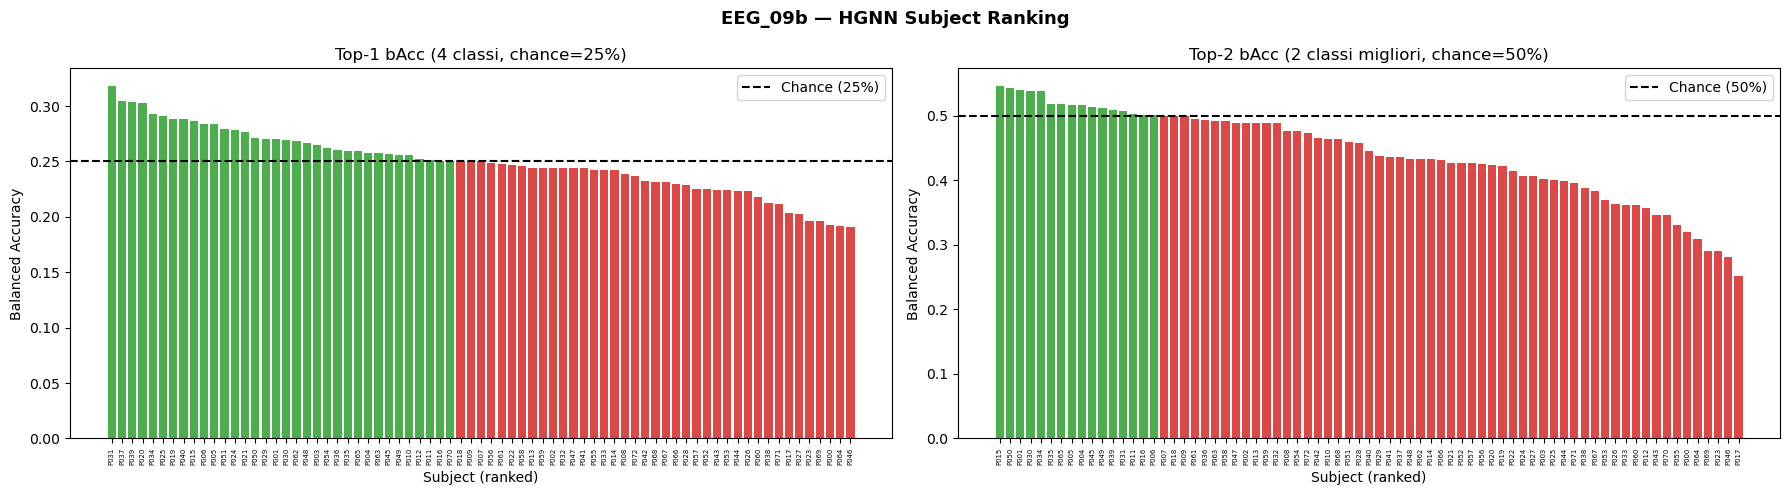

In [7]:
if 'df_top1' not in dir():
    print('[INFO] Esegui prima §6.')
else:
    chance1 = 1/N_CLASSES
    chance2 = 0.5

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
    fig.suptitle('EEG_09b — HGNN Subject Ranking', fontsize=13, fontweight='bold')

    for ax, df, col, chance, title in [
        (ax1, df_top1, 'Test bAcc', chance1, f'Top-1 bAcc (4 classi, chance={chance1:.0%})'),
        (ax2, df_top2, 'Top2 bAcc', chance2, f'Top-2 bAcc (2 classi migliori, chance={chance2:.0%})')
    ]:
        vals = df[col].values
        colors = ['#2ca02c' if v > chance else '#d62728' for v in vals]
        ax.bar(range(len(vals)), vals, color=colors, alpha=0.85, edgecolor='none')
        ax.axhline(chance, color='black', ls='--', lw=1.5, label=f'Chance ({chance:.0%})')
        ax.set_xticks(range(len(vals))); ax.set_xticklabels(df['Subject'], rotation=90, fontsize=5)
        ax.set_xlabel('Subject (ranked)'); ax.set_ylabel('Balanced Accuracy')
        ax.set_title(title); ax.legend()

    plt.tight_layout()
    plt.savefig(FIG_DIR/'eeg09b_ranking.png', dpi=150, bbox_inches='tight')
    plt.show()

## §8 — Confusion Matrix Top-5

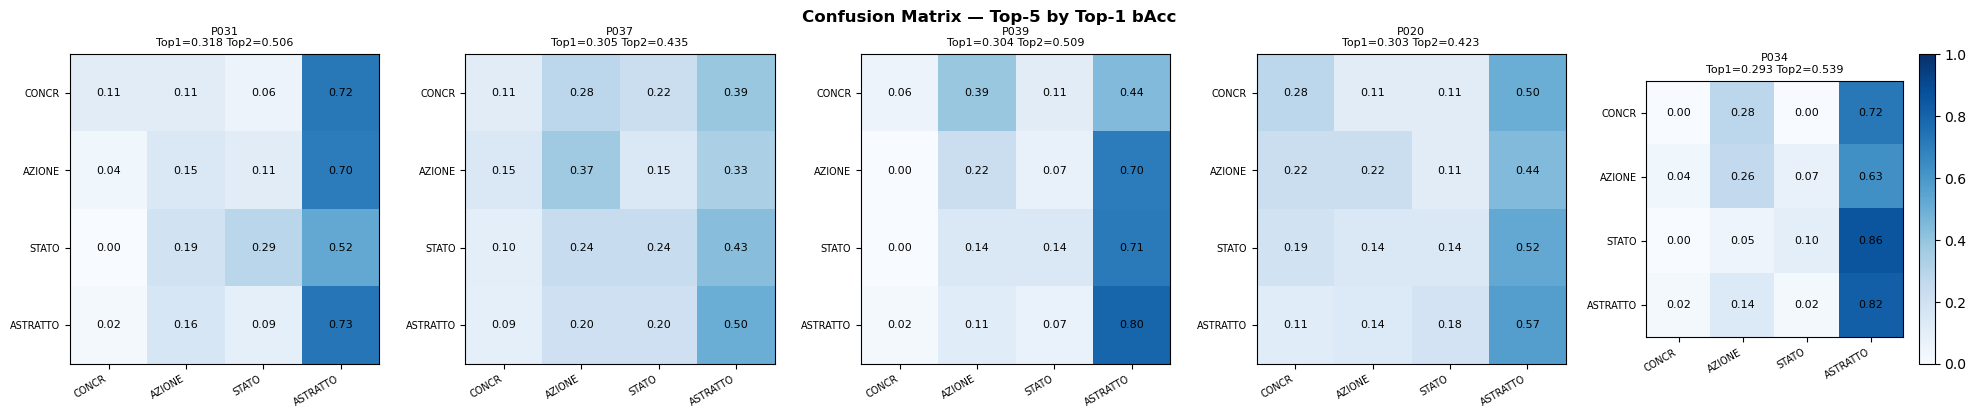

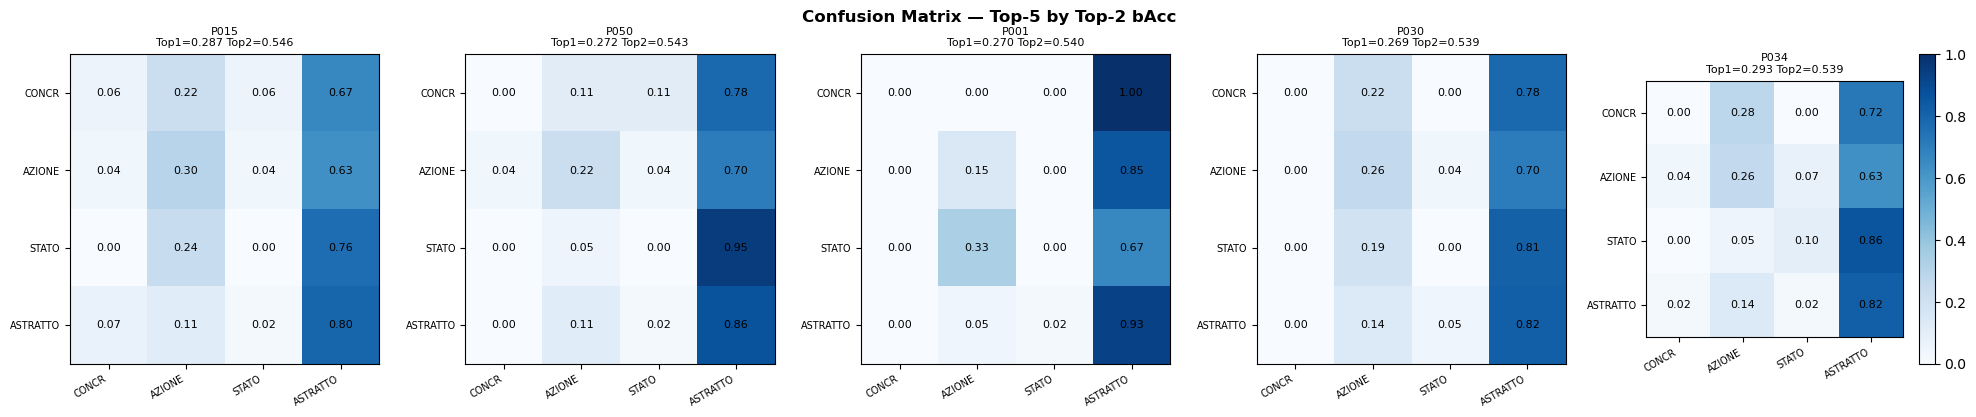

In [8]:
if 'df_top1' not in dir():
    print('[INFO] Esegui prima §6.')
else:
    from sklearn.metrics import confusion_matrix

    CLASS_NAMES = ['CONCR','AZIONE','STATO','ASTRATTO']

    def plot_cm_grid(df_ranking, col, title_prefix, fname):
        top5 = df_ranking.head(5)
        fig, axes = plt.subplots(1, 5, figsize=(20, 4))
        fig.suptitle(f'Confusion Matrix — Top-5 by {title_prefix}', fontsize=12, fontweight='bold')
        for ax, (_, row) in zip(axes, top5.iterrows()):
            sid = int(row['Subject'][1:])
            res = SUBJECT_RESULTS.get(sid)
            if res is None or 'labels' not in res:
                ax.set_title(row['Subject']); ax.axis('off'); continue
            lbl = np.array(res['labels']); pred = np.array(res['preds'])
            cm = confusion_matrix(lbl, pred, labels=list(range(N_CLASSES)), normalize='true')
            im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
            ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(CLASS_NAMES, fontsize=7, rotation=30, ha='right')
            ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(CLASS_NAMES, fontsize=7)
            for i in range(N_CLASSES):
                for j in range(N_CLASSES):
                    ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center', fontsize=8)
            ax.set_title(f'{row["Subject"]}\nTop1={row["Test bAcc"]:.3f} Top2={row["Top2 bAcc"]:.3f}', fontsize=8)
        plt.colorbar(im, ax=axes[-1])
        plt.tight_layout()
        plt.savefig(FIG_DIR/fname, dpi=150, bbox_inches='tight')
        plt.show()

    if any('labels' in r for r in SUBJECT_RESULTS.values()):
        plot_cm_grid(df_top1, 'Test bAcc', 'Top-1 bAcc', 'eeg09b_cm_top1.png')
        plot_cm_grid(df_top2, 'Top2 bAcc', 'Top-2 bAcc', 'eeg09b_cm_top2.png')
    else:
        print('[INFO] labels/preds non disponibili — riesegui §5.')